# Komplettlauf: die verkettete End-to-End-Pipeline

Dieses Notebook wertet den **Full Run** aus – die zusammenhängende \ac{ETL}-Strecke,
bei der jedes Modell alle neun Schritte nacheinander durchläuft und die Ausgabe eines
Schritts die Eingabe des nächsten ist (`scripts/run_pipeline.py`).

Der Unterschied zu den drei Kategorie-Notebooks ist entscheidend: Dort bekommt **jede
Aufgabe die rohen, dreckigen Daten** und wird unabhängig bewertet. Hier arbeitet jeder
Schritt auf dem Ergebnis seiner Vorgänger. Damit werden zwei Effekte messbar, die die
unabhängigen Läufe nicht zeigen können:

- **Vorbereitung:** Spätere Schritte profitieren von bereits normalisierten Daten
  (die Schlüssel-Deduplizierung kann nach ISO-Datumsformat sauber sortieren).
- **Fehlerfortpflanzung und Kaskaden-Abbruch:** Eine kleine Abweichung in einem frühen
  Schritt pflanzt sich fort; ein Absturz blockiert alle abhängigen Folgeschritte.

Als fünfter Teilnehmer läuft die **regelbasierte Baseline** dieselbe Kette
(`python scripts/run_pipeline.py --providers baseline`). Sie nutzt für die
formalisierbaren Schritte dieselben deterministischen Routinen wie die Referenz und
für die beiden semantischen Schritte ihre begrenzten Heuristiken – dadurch wird
sichtbar, wie sich deren Schwächen in der Kette fortpflanzen.

Kennzahl ist wie überall die **abgeglichene Genauigkeit**, gemessen gegen eine
*verkettete Referenz*: dieselbe Schrittfolge, ausgeführt mit den regelbasierten
Referenzfunktionen. Je Schritt sind bis zu drei Versuche erlaubt (Retry nach Absturz
oder unvollständigem Schema).

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reporting import pipeline_analysis as pa
from reporting import compare
from reporting.analysis import PROVIDER_LABEL, load_runs
from experiments.pipeline_runner import PIPELINE

seed = 1
pipe = pa.load_pipeline(seed)
PROVS = [p for p in pa.PIPE_ORDER if p in set(pipe.provider)]  # Modelle + regelbasierte Baseline
LABELS = [PROVIDER_LABEL[p] for p in PROVS]
STEPS = [s.name for s in PIPELINE]
STEP_LABELS = [s.label for s in PIPELINE]

print(f"Seed {seed}: {len(PROVS)} Teilnehmer x {len(STEPS)} Schritte = {len(pipe)} Schritt-Laeufe")
print(f"Grafiken werden gespeichert unter: {compare.FIG_DIR}")
pipe.head()

Seed 1: 5 Teilnehmer x 9 Schritte = 45 Schritt-Laeufe
Grafiken werden gespeichert unter: C:\Users\geige\Desktop\DHBW\Bachelorarbeit\project\figures


,provider,label,step,step_label,order,status,accuracy,attempts,error,duration_s,llm_s,exec_s,cost_usd,prompt_tokens,completion_tokens,row_actual,row_expected,model
0,anthropic,Claude,cleaning_easy,1 · Bereinigung: Leerzeichen & fehlende Werte,0,ok,1.000000,1,NaN,NaN,NaN,NaN,0.006390,450,336,540.0,540.0,claude-sonnet-5
1,anthropic,Claude,cleaning_medium,2 · Bereinigung: Datumsformate,1,ok,1.000000,1,NaN,NaN,NaN,NaN,0.014811,502,887,540.0,540.0,claude-sonnet-5
2,anthropic,Claude,cleaning_hard,3 · Bereinigung: Ländercodes (ISO),2,ok,0.976296,1,NaN,NaN,NaN,NaN,0.039963,516,2561,540.0,540.0,claude-sonnet-5
3,anthropic,Claude,dedup_easy,4 · Deduplizierung: exakte Duplikate,3,ok,0.970192,1,NaN,NaN,NaN,NaN,0.003981,437,178,520.0,520.0,claude-sonnet-5
4,anthropic,Claude,dedup_medium,5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),4,ok,0.970331,1,NaN,NaN,NaN,NaN,0.004995,475,238,514.0,514.0,claude-sonnet-5


## 1 · Verlauf der Pipeline auf einen Blick

Zeilen = Schritte (von oben nach unten der Datenfluss), Spalten = Modelle. Grüne Felder
zeigen die Genauigkeit des Schritts, rote den Abbruch, graue die dadurch blockierten
Folgeschritte (`figures/pipeline_verlauf.png`).

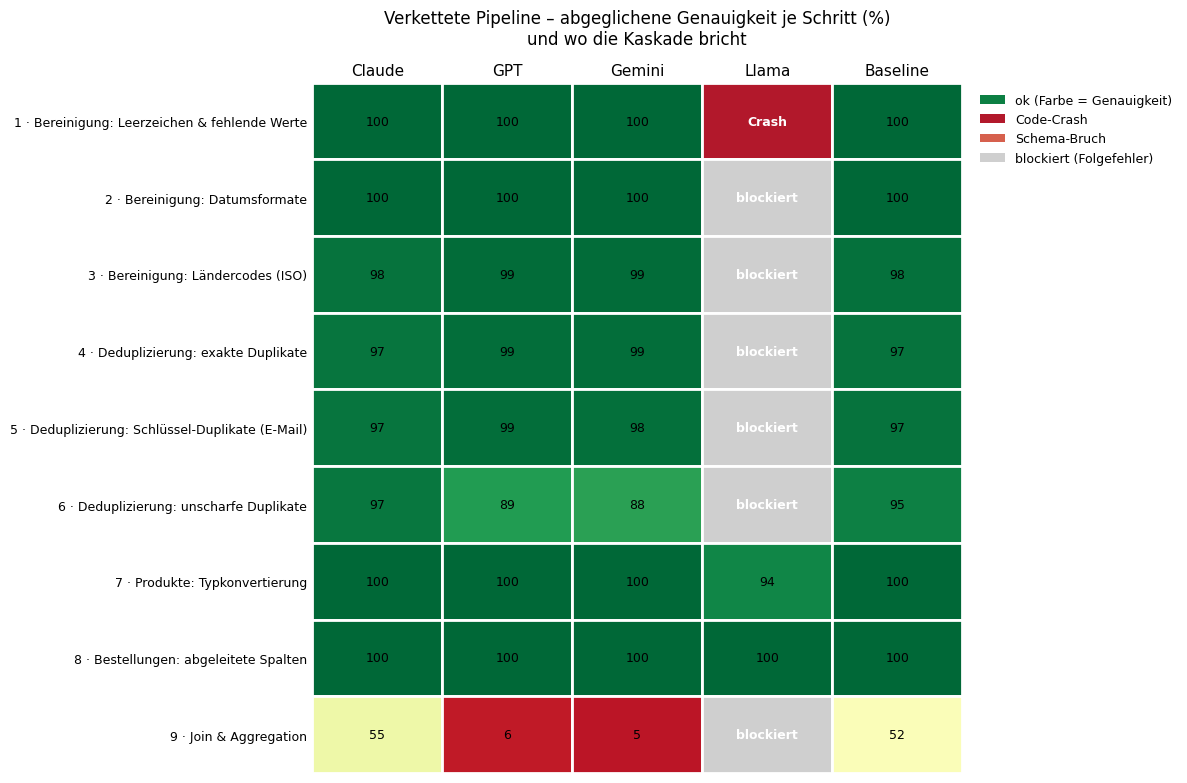

In [2]:
fig, _ = pa.pipeline_heatmap(seed); plt.show()

## 2 · Zusammenfassung je Modell

Wie weit kommt jedes Modell, wo bricht die Kette, und mit welcher Endgenauigkeit
schließt der letzte Schritt ab?

,Schritte ok,Ende erreicht,Endgenauigkeit,Erster Abbruch
Modell,,,,
Claude,9/9,ja,54.5%,—
GPT,9/9,ja,5.6%,—
Gemini,9/9,ja,4.5%,—
Llama,2/9,nein,—,1 · Bereinigung: Leerzeichen & fehlende Werte
Baseline,9/9,ja,51.5%,—


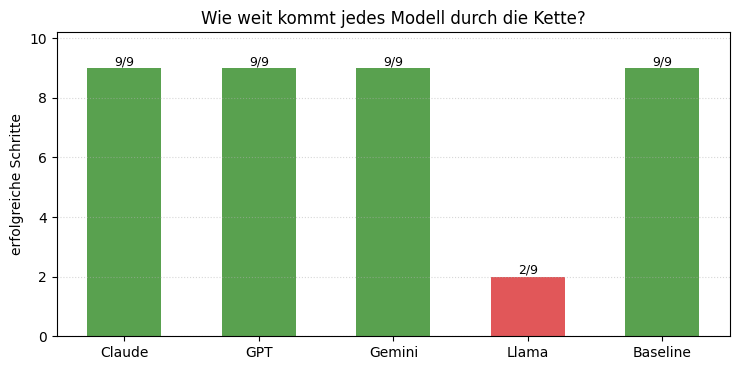

In [3]:
summary = pa.pipeline_summary(seed)
display(summary)

ok_steps = [int((pipe[pipe.provider == p].status == "ok").sum()) for p in PROVS]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
bars = ax.bar(LABELS, ok_steps, 0.55,
              color=["#59a14f" if n == len(STEPS) else "#e15759" for n in ok_steps])
for r, n in zip(bars, ok_steps):
    ax.text(r.get_x() + r.get_width() / 2, n, f"{n}/{len(STEPS)}", ha="center",
            va="bottom", fontsize=9)
ax.set_ylim(0, len(STEPS) + 1.2)
ax.set_ylabel("erfolgreiche Schritte")
ax.set_title("Wie weit kommt jedes Modell durch die Kette?")
ax.grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "pipeline_schritte_ok"); plt.show()

## 3 · Genauigkeit entlang der Schrittfolge

Der Verlauf zeigt, ob die Qualität über die Kette hinweg stabil bleibt. Ein `x` markiert
den Abbruch eines Modells, eine Lücke die dadurch blockierten Schritte
(`figures/pipeline_genauigkeit.png`).

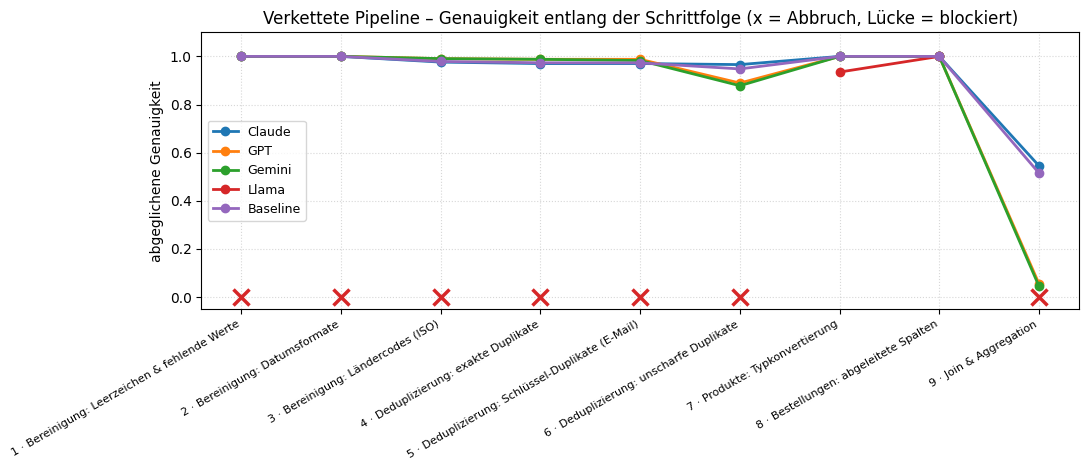

,Claude,GPT,Gemini,Llama,Baseline
1 · Bereinigung: Leerzeichen & fehlende Werte,100.0,100.0,100.0,NaN,100.0
2 · Bereinigung: Datumsformate,100.0,100.0,100.0,NaN,100.0
3 · Bereinigung: Ländercodes (ISO),97.6,99.1,99.1,NaN,97.9
4 · Deduplizierung: exakte Duplikate,97.0,98.8,98.8,NaN,97.4
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),97.0,98.8,98.3,NaN,97.3
6 · Deduplizierung: unscharfe Duplikate,96.6,88.9,87.8,NaN,94.8
7 · Produkte: Typkonvertierung,100.0,100.0,100.0,93.5,100.0
8 · Bestellungen: abgeleitete Spalten,100.0,100.0,100.0,100.0,100.0
9 · Join & Aggregation,54.5,5.6,4.5,NaN,51.5


In [4]:
fig, _ = pa.step_accuracy(seed); plt.show()

acc_tab = pipe.pivot_table(index="step", columns="provider", values="accuracy",
                           aggfunc="first").reindex(STEPS)
acc_tab = acc_tab[[p for p in PROVS if p in acc_tab.columns]]
acc_tab.index = STEP_LABELS
acc_tab.columns = [PROVIDER_LABEL[c] for c in acc_tab.columns]
status_tab = pipe.pivot_table(index="step", columns="provider", values="status",
                              aggfunc="first").reindex(STEPS)
status_tab.index = STEP_LABELS
display((acc_tab * 100).round(1))

## 4 · Aufwand: Kosten und Versuche

Die Pipeline ist deutlich günstiger als die vollständige Matrix, weil jedes Modell jeden
Schritt nur einmal (plus ggf. Retries) ausführt. Rechts wird sichtbar, wo ein Modell
Nachbesserungsversuche gebraucht hat (`figures/pipeline_aufwand.png`).

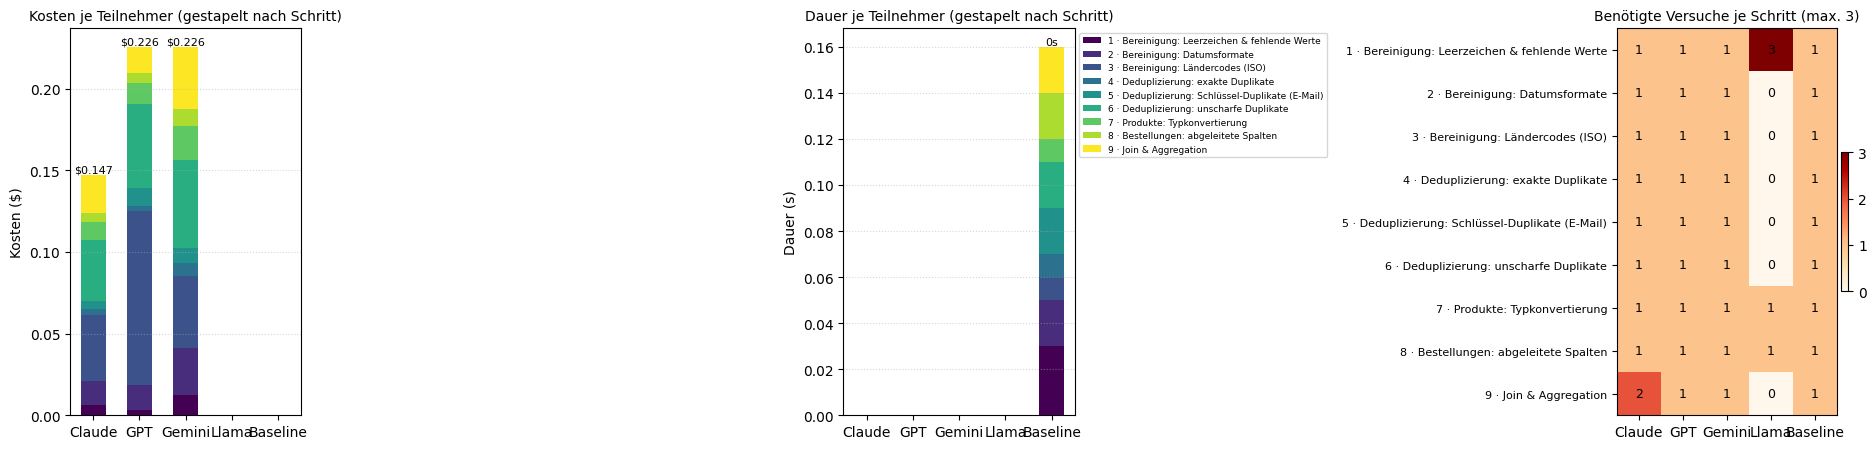

,kosten,dauer_s,modellzeit_s,skriptzeit_s,tok_in,tok_out,versuche,schritte_ok,Kosten je ok-Schritt
Claude,0.1472,0.00,0.0,0.00,5257,8759,10,9,0.0164
GPT,0.2255,0.00,0.0,0.00,2799,14570,9,9,0.0251
Gemini,0.2255,0.00,0.0,0.00,3008,29466,9,9,0.0251
Llama,0.0000,0.00,0.0,0.00,1496,1223,5,2,0.0000
Baseline,0.0000,0.16,0.0,0.16,0,0,9,9,0.0000


In [5]:
fig, _ = pa.effort(seed); plt.show()

kosten = (pipe.groupby("provider")
          .agg(kosten=("cost_usd", "sum"), dauer_s=("duration_s", "sum"),
               modellzeit_s=("llm_s", "sum"), skriptzeit_s=("exec_s", "sum"),
               tok_in=("prompt_tokens", "sum"),
               tok_out=("completion_tokens", "sum"), versuche=("attempts", "sum"),
               schritte_ok=("status", lambda s: int((s == "ok").sum())))
          .reindex(PROVS))
kosten.index = LABELS
kosten["Kosten je ok-Schritt"] = (kosten.kosten / kosten.schritte_ok).round(4)
kosten.round(4)

Dauer je Schritt in Sekunden. Der Löwenanteil ist die Antwortzeit des Modells – das
erzeugte pandas-Skript selbst läuft in Bruchteilen einer Sekunde, und die
regelbasierte Baseline durchläuft die komplette Kette in unter einer Zehntelsekunde.
Läufe, die vor Einführung der Zeitmessung entstanden sind, erscheinen als `NaN`.


In [6]:
pa.step_durations(seed)


,davon Modell (Ø),davon Skript (Ø),Claude,GPT,Gemini,Llama,Baseline
1 · Bereinigung: Leerzeichen & fehlende Werte,NaN,NaN,NaN,NaN,NaN,NaN,0.03
2 · Bereinigung: Datumsformate,NaN,NaN,NaN,NaN,NaN,NaN,0.02
3 · Bereinigung: Ländercodes (ISO),NaN,NaN,NaN,NaN,NaN,NaN,0.01
4 · Deduplizierung: exakte Duplikate,NaN,NaN,NaN,NaN,NaN,NaN,0.01
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),NaN,NaN,NaN,NaN,NaN,NaN,0.02
6 · Deduplizierung: unscharfe Duplikate,NaN,NaN,NaN,NaN,NaN,NaN,0.02
7 · Produkte: Typkonvertierung,NaN,NaN,NaN,NaN,NaN,NaN,0.01
8 · Bestellungen: abgeleitete Spalten,NaN,NaN,NaN,NaN,NaN,NaN,0.02
9 · Join & Aggregation,NaN,NaN,NaN,NaN,NaN,NaN,0.02


## 5 · Verkettete Pipeline gegen unabhängige Einzelläufe

Dieselbe Aufgabe einmal in der Kette (auf vorbereiteten Daten) und einmal als
unabhängiger Einzellauf auf den Rohdaten – jeweils gemittelt über die Modelle. Für den
Einzellauf wird die **beste klassische Prompt-Strategie** herangezogen, also der faire
Bestfall (`figures/pipeline_vs_einzellauf.png`).

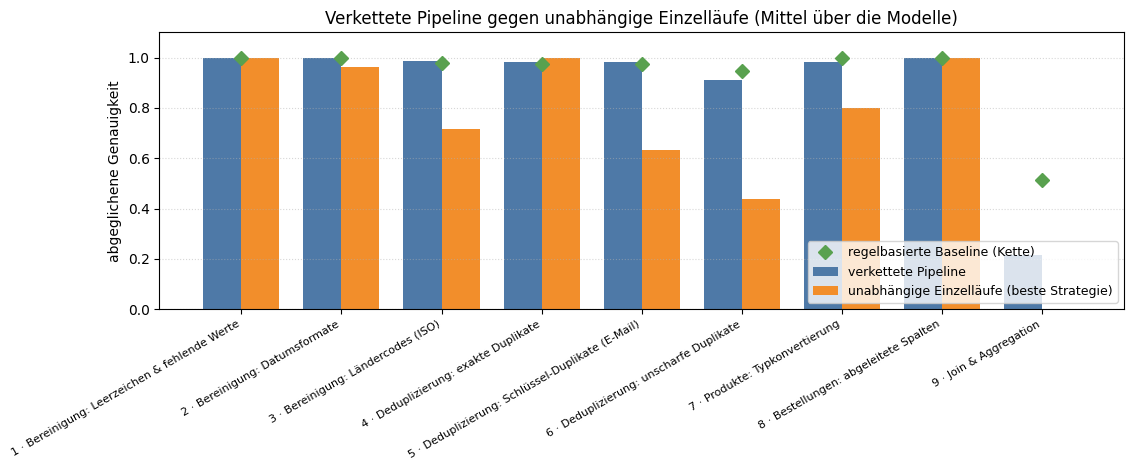

,Pipeline (Ø Modelle),"Einzellauf (beste Strategie, Ø Modelle)",Baseline (Kette),Differenz
Schritt,,,,
1 · Bereinigung: Leerzeichen & fehlende Werte,100.0,100.0,100.0,0.0
2 · Bereinigung: Datumsformate,100.0,96.4,100.0,3.6
3 · Bereinigung: Ländercodes (ISO),98.6,71.5,97.9,27.1
4 · Deduplizierung: exakte Duplikate,98.2,100.0,97.4,-1.8
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),98.0,63.3,97.3,34.7
6 · Deduplizierung: unscharfe Duplikate,91.1,43.8,94.8,47.3
7 · Produkte: Typkonvertierung,98.4,80.1,100.0,18.3
8 · Bestellungen: abgeleitete Spalten,100.0,100.0,100.0,0.0
9 · Join & Aggregation,21.5,0.1,51.5,21.5


In [7]:
runs = load_runs(seed=seed, include_baseline=True)
fig, T = pa.pipeline_vs_matrix(runs, seed); plt.show()
(T * 100).round(1)

## 6 · Fehlerfortpflanzung im Endschritt

Der Endschritt (Join & Aggregation) fällt bei allen Modellen deutlich ab, obwohl Schema
und Zeilenzahl stimmen und die Gruppierungsschlüssel vollständig getroffen werden. Die
Ursache liegt **nicht** im Endschritt selbst: Weil die Deduplizierung stromaufwärts
andere Kundenzeilen entfernt als die Referenz, fallen beim Join andere Bestellungen
heraus – und jede betroffene Gruppe zählt in Umsatz *und* Bestellanzahl als falsch.

In [8]:
diag = pa.final_step_diagnosis(seed)
display(diag)

,Zeilen Ist,Zeilen Soll,Schluessel-Treffer,total_revenue_eur korrekt,order_count korrekt
Modell,,,,,
Claude,66,66,66/66,54.5,54.5
GPT,72,66,66/66,6.1,6.1
Gemini,66,66,66/66,4.5,4.5
Baseline,66,66,66/66,51.5,51.5


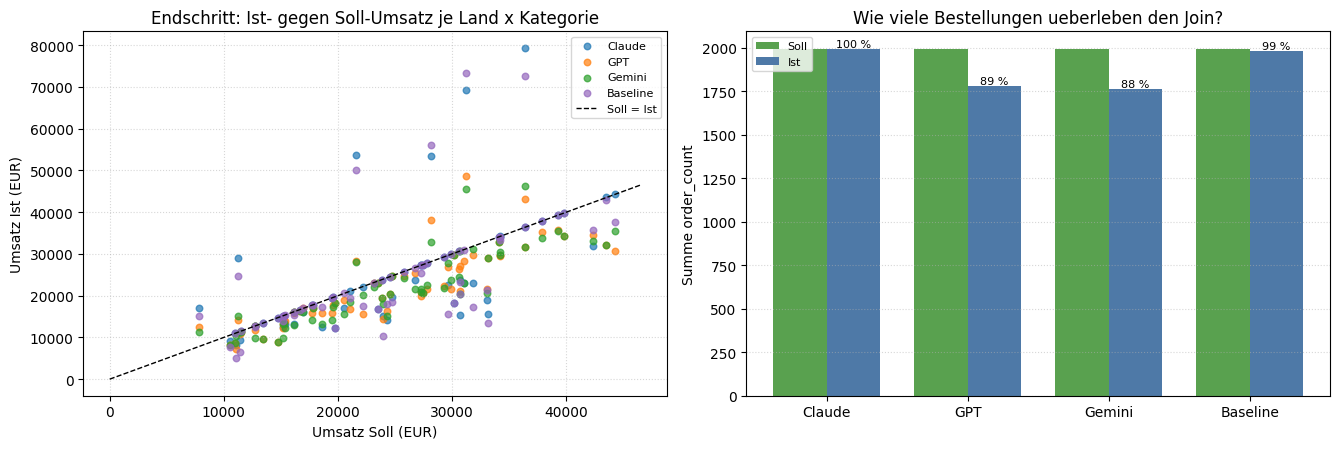

,Bestellungen Soll,Bestellungen Ist,Umsatz Soll,Umsatz Ist,Gruppen exakt %
Modell,,,,,
Claude,1995,1995,1605337.12,1605337.12,54.5
GPT,1995,1783,1605337.12,1429450.01,6.1
Gemini,1995,1764,1605337.12,1415742.98,4.5
Baseline,1995,1980,1605337.12,1591870.61,51.5


In [9]:
from experiments.pipeline_runner import build_chain_reference
exp = build_chain_reference(seed)["final"]
keys = ["country_code", "category"]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
rows = []
for i, prov in enumerate(PROVS):
    p = pa.PIPELINE_RESULTS / str(seed) / prov / "final" / "output.parquet"
    if not p.exists():
        continue
    act = pd.read_parquet(p)[exp.columns]
    m = exp.merge(act, on=keys, suffixes=("_soll", "_ist"))
    axes[0].scatter(m.total_revenue_eur_soll, m.total_revenue_eur_ist, s=22,
                    alpha=0.7, color=f"C{i}", label=PROVIDER_LABEL[prov])
    rows.append({"Modell": PROVIDER_LABEL[prov],
                 "Bestellungen Soll": int(m.order_count_soll.sum()),
                 "Bestellungen Ist": int(m.order_count_ist.sum()),
                 "Umsatz Soll": round(float(m.total_revenue_eur_soll.sum()), 2),
                 "Umsatz Ist": round(float(m.total_revenue_eur_ist.sum()), 2),
                 "Gruppen exakt %": round(float((m.total_revenue_eur_soll
                                                 - m.total_revenue_eur_ist).abs().le(0.01).mean()) * 100, 1)})
lim = float(exp.total_revenue_eur.max()) * 1.05
axes[0].plot([0, lim], [0, lim], "k--", lw=1, label="Soll = Ist")
axes[0].set_xlabel("Umsatz Soll (EUR)")
axes[0].set_ylabel("Umsatz Ist (EUR)")
axes[0].set_title("Endschritt: Ist- gegen Soll-Umsatz je Land x Kategorie")
axes[0].legend(fontsize=8)
axes[0].grid(ls=":", alpha=0.5)

V = pd.DataFrame(rows).set_index("Modell")
x = np.arange(len(V))
axes[1].bar(x - 0.19, V["Bestellungen Soll"], 0.38, color="#59a14f", label="Soll")
axes[1].bar(x + 0.19, V["Bestellungen Ist"], 0.38, color="#4e79a7", label="Ist")
for i, (s, a) in enumerate(zip(V["Bestellungen Soll"], V["Bestellungen Ist"])):
    axes[1].text(i + 0.19, a, f"{a / s * 100:.0f} %", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(V.index)
axes[1].set_ylabel("Summe order_count")
axes[1].set_title("Wie viele Bestellungen ueberleben den Join?")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", ls=":", alpha=0.5)
fig.tight_layout(); compare.save_fig(fig, "pipeline_fehlerfortpflanzung"); plt.show()
display(V)

In [10]:
# Woher kommt die Abweichung? Zeilenzahlen der Kundentabelle entlang der Kette.
chain = build_chain_reference(seed)
rowtab = pipe[pipe.step.isin(STEPS)].pivot_table(
    index="step", columns="provider", values="row_actual", aggfunc="first").reindex(STEPS)
rowtab = rowtab[[p for p in PROVS if p in rowtab.columns]]
rowtab.columns = [PROVIDER_LABEL[c] for c in rowtab.columns]
rowtab.insert(0, "Soll", [len(chain[s]) for s in STEPS])
rowtab.index = STEP_LABELS
rowtab

,Soll,Claude,GPT,Gemini,Llama,Baseline
1 · Bereinigung: Leerzeichen & fehlende Werte,540,540.0,540.0,540.0,NaN,540.0
2 · Bereinigung: Datumsformate,540,540.0,540.0,540.0,NaN,540.0
3 · Bereinigung: Ländercodes (ISO),540,540.0,540.0,540.0,NaN,540.0
4 · Deduplizierung: exakte Duplikate,520,520.0,520.0,520.0,NaN,520.0
5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),514,514.0,514.0,514.0,NaN,514.0
6 · Deduplizierung: unscharfe Duplikate,497,500.0,450.0,446.0,NaN,505.0
7 · Produkte: Typkonvertierung,100,100.0,100.0,100.0,100.0,100.0
8 · Bestellungen: abgeleitete Spalten,2000,2000.0,2000.0,2000.0,2000.0,2000.0
9 · Join & Aggregation,66,66.0,72.0,66.0,NaN,66.0


## 7 · Abbrüche im Detail

Für jeden nicht erfolgreichen Schritt die protokollierte Ursache. Das lokale Modell
scheitert bereits am ersten Schritt und blockiert damit die gesamte Kundenstrecke; die
beiden von den Rohdaten gespeisten Nebenstränge (Produkte, Bestellungen) laufen trotzdem
durch.

In [11]:
fehler = pipe[pipe.status != "ok"].copy()
if len(fehler):
    fehler["Modell"] = fehler.provider.map(PROVIDER_LABEL)
    fehler["Fehler (gekuerzt)"] = fehler.error.fillna("").str.replace(r"\s+", " ", regex=True).str[:180]
    display(fehler[["Modell", "step_label", "status", "attempts", "Fehler (gekuerzt)"]]
            .reset_index(drop=True))
    for _, r in fehler[fehler.status == "code_error"].iterrows():
        print(f"\n--- {PROVIDER_LABEL[r.provider]} | {r.step_label} "
              f"(nach {r.attempts} Versuchen)\n{r.error}")
else:
    print("Kein Schritt abgebrochen.")

,Modell,step_label,status,attempts,Fehler (gekuerzt)
0,Llama,1 · Bereinigung: Leerzeichen & fehlende Werte,code_error,3,"Code-Ausführung fehlgeschlagen: le ""pandas/_li..."
1,Llama,2 · Bereinigung: Datumsformate,blocked,0,Vorheriger Schritt fehlgeschlagen
2,Llama,3 · Bereinigung: Ländercodes (ISO),blocked,0,Vorheriger Schritt fehlgeschlagen
3,Llama,4 · Deduplizierung: exakte Duplikate,blocked,0,Vorheriger Schritt fehlgeschlagen
4,Llama,5 · Deduplizierung: Schlüssel-Duplikate (E-Mail),blocked,0,Vorheriger Schritt fehlgeschlagen
5,Llama,6 · Deduplizierung: unscharfe Duplikate,blocked,0,Vorheriger Schritt fehlgeschlagen
6,Llama,9 · Join & Aggregation,blocked,0,Vorheriger Schritt fehlgeschlagen



--- Llama | 1 · Bereinigung: Leerzeichen & fehlende Werte (nach 3 Versuchen)
Code-Ausführung fehlgeschlagen: le "pandas/_libs/tslibs/conversion.pyx", line 658, in pandas._libs.tslibs.conversion.convert_str_to_tsobject
  File "pandas/_libs/tslibs/parsing.pyx", line 321, in pandas._libs.tslibs.parsing.parse_datetime_string
  File "pandas/_libs/tslibs/parsing.pyx", line 674, in pandas._libs.tslibs.parsing.dateutil_parse
pandas._libs.tslibs.parsing.DateParseError: year 1639353600 is out of range: 1639353600



Der Beleg dafür steckt im dritten Schritt: Wer dort mehr Länder auf `UNKNOWN`
zurückfallen lässt, verschiebt die betroffenen Kunden im Endschritt in die falsche
Ländergruppe – und zwar in *jeder* Kennzahl gleichzeitig.

Die Zerlegung trennt die drei möglichen Ursachen: Ist die Aggregation selbst falsch,
kostet die Wahl des Duplikat-Repräsentanten, oder sind es die Ländercodes? Spalte 1
wendet die Referenzlogik auf **dieselben Zwischenstände** an – ein Wert von 1,0 heißt,
dass der Endschritt fehlerfrei rechnet und der gesamte Fehler geerbt ist.


In [12]:
pa.final_step_decomposition(seed)


,eigener Code korrekt,nur Dedup-Effekt,Endergebnis,verwaiste Bestellungen
Teilnehmer,,,,
Claude,1.000,1.000,0.545,5
GPT,0.917,0.091,0.056,217
Gemini,1.000,0.076,0.045,236
Baseline,1.000,0.833,0.515,20


In [13]:
# Beleg fuer die Ursache: wie viele Kunden bekommen im 3. Schritt den falschen Laendercode?
# Achtung: 20 customer_id kommen doppelt vor (Fuzzy-Zwillinge tragen eine eigene ID, exakte
# Duplikate teilen sie) -- ein Merge auf customer_id wuerde die Zeilen aufblaehen. Der Schritt
# erhaelt Zeilenzahl und -reihenfolge, deshalb wird positionsweise verglichen.
e = chain["cleaning_hard"]
rows = []
ok_provs = [p for p in PROVS if not pipe[(pipe.provider == p) & (pipe.step == "cleaning_hard")
                                          & (pipe.status == "ok")].empty]
for prov in ok_provs:  # nur Modelle, die den Schritt in diesem Lauf bestanden haben
    a = pd.read_parquet(pa.PIPELINE_RESULTS / str(seed) / prov / "cleaning_hard" / "output.parquet")
    if len(a) != len(e) or a.customer_id.astype(str).tolist() != e.customer_id.astype(str).tolist():
        rows.append({"Modell": PROVIDER_LABEL[prov], "Hinweis": "Zeilenreihenfolge abweichend"})
        continue
    bad = a.country.astype(str).values != e.country.astype(str).values
    roh = pd.read_parquet(pa.PIPELINE_RESULTS / str(seed) / prov / "cleaning_medium" / "output.parquet")
    rows.append({
        "Modell": PROVIDER_LABEL[prov],
        "falsche Laendercodes": int(bad.sum()),
        "Anteil %": round(float(bad.mean()) * 100, 1),
        "davon UNKNOWN": int((a.country.astype(str).values[bad] == "UNKNOWN").sum()),
        "nicht erkannte Schreibweisen": ", ".join(
            f"{k} ({v})" for k, v in roh.country.astype(str).values[bad].tolist()
            and pd.Series(roh.country.astype(str).values[bad]).value_counts().head(5).items()),
    })
pd.DataFrame(rows).set_index("Modell")

,falsche Laendercodes,Anteil %,davon UNKNOWN,nicht erkannte Schreibweisen
Modell,,,,
Claude,64,11.9,64,"England (17), Holland (14), SUI (14), Deutshcl..."
GPT,25,4.6,25,"Deutshcland (11), Großbritannien (7), OEsterre..."
Gemini,25,4.6,25,"SUI (14), Deutshcland (11)"
Baseline,57,10.6,57,"England (17), Holland (14), Deutshcland (11), ..."


## 8 · Kernaussagen des Komplettlaufs (Seed 1)

- **Vier von fünf Teilnehmern** (Claude, GPT, Gemini, Baseline) durchlaufen alle neun
  Schritte ohne Abbruch; das lokale Llama scheitert **schon am ersten Schritt**
  (Code-Crash nach drei Versuchen: ein Unix-Timestamp wird als Jahreszahl geparst) und
  blockiert damit die komplette Kundenstrecke. Nur die beiden direkt von den Rohdaten
  gespeisten Nebenstränge (Produkte, Bestellungen) laufen bei ihm durch – 2 von 9.
- **Die Kette selbst funktioniert sehr gut:** Über die ersten acht Schritte liegen alle
  drei Modelle zwischen 95 % und 99 % abgeglichener Genauigkeit, und die Zeilenzahlen
  folgen der Referenz Schritt für Schritt (540 → 520 → 514 → 500 gegenüber 497 im Soll).
- **Retries sind kaum nötig:** Bis auf zwei Anläufe von Gemini gelingt jeder Schritt im
  ersten Versuch. Die Pipeline kostet 0,13–0,35 $ je Modell und ist damit um
  Größenordnungen günstiger als die vollständige Aufgaben-Matrix (6,57 $).
- **Vorbereitete Daten helfen deutlich.** Gegenüber den unabhängigen Einzelläufen auf
  Rohdaten gewinnen genau die Schritte, die auf Vorarbeit angewiesen sind: unscharfe
  Duplikate +51,5, Schlüssel-Duplikate +32,1, ISO-Ländercodes +25,1 Prozentpunkte. Die
  Schlüssel-Deduplizierung kann in der Kette nach bereits normalisiertem ISO-Datum
  sortieren – auf den Rohdaten scheitert sie an gemischten Datumsformaten.
- **Fehlerfortpflanzung ist der eigentliche Befund des Komplettlaufs.** Der Endschritt
  fällt auf 36–64 %, obwohl Schema, Zeilenzahl (66) und alle 66 Gruppenschlüssel stimmen
  und die Aggregation selbst **nachweislich fehlerfrei** rechnet (Spalte „eigener Code
  korrekt" = 1,0 bei allen Teilnehmern). Der gesamte Fehler stammt aus den Vorstufen:
  falsch zugeordnete Ländercodes verschieben Kunden zwischen den Gruppen, ein anders
  gewählter Duplikat-Repräsentant lässt Bestellungen aus dem Join fallen.
- **Kleine Abweichung, große Wirkung:** Zwischen 7,8 % (Gemini) und 22,4 % (Baseline)
  falscher Ländercodes in Schritt 3 führen zu 42 bzw. nur 10 von 66 exakt getroffenen
  Gruppen im Endergebnis. Eine Aggregation ist ein Verstärker – ein einziger falsch
  einsortierter Kunde macht zwei Gruppen in beiden Kennzahlen falsch.
- **Die regelbasierte Baseline zeigt dasselbe Muster.** In den formalisierbaren
  Schritten ist sie perfekt (1, 2, 7, 8 mit 100 %). Ihre Ländertabelle deckt volle
  Namen, ISO-3166-1 alpha-2 und die gängigen IOC-Codes ab (GER, SUI, AUT, ESP …),
  scheitert aber weiter an Tippfehlern, Umschriften und umgangssprachlichen Namen
  (England, Holland, UK, Deutshcland, OEsterreich): 57 von 540 Zuordnungen (10,6 %)
  landen fälschlich auf `UNKNOWN`. Dazu verliert ihre Fuzzy-Heuristik in Schritt 6
  fünf Original-Datensätze (20 verwaiste Bestellungen). Im Endschritt erreicht sie
  damit 51,5 % – besser als Claude (43,9 %) und GPT (36,4 %), aber hinter Gemini
  (63,6 %). Die Zerlegung zeigt, woran es liegt: mit korrigierten Ländercodes käme
  sie auf 83,3 %, der Rest ist reiner Dedup-Effekt.
- Für die Praxis heißt das: In verketteten \ac{ETL}-Strecken entscheidet die
  Qualität der frühen, semantisch geprägten Schritte über das Endergebnis, und eine
  Zwischenprüfung nach jedem Schritt ist wirksamer als eine Endkontrolle.